## İmport Library and Dataset

In [3]:
import pandas as pd
import numpy as np

!pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
%pip install xgboost lightgbm
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


ModuleNotFoundError: No module named 'pandas'

## Data

In [ ]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Finding rows where TotalCharges is just an empty space

blank_rows = df[df['TotalCharges'].str.strip() == '']

print(f"Number of rows with empty spaces: {len(blank_rows)}")
print("\nList of rows with empty spaces:")
blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Number of rows with empty spaces: 11

List of rows with empty spaces:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

In [ ]:
# 1. Convert TotalCharges to numeric, turning empty spaces into NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# 2. Fill the NaN values with 0 for the new customers (tenure = 0)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
# 3. Verification: Check if the data type changed to float and if any missing values remain

print(df[['TotalCharges']].info())
print("\nVerification of the customers with tenure = 0:")
df[df['tenure'] == 0][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TotalCharges  7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB
None

Verification of the customers with tenure = 0:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0
3331,7644-OMVMY,0,19.85,0.0
3826,3213-VVOLG,0,25.35,0.0
4380,2520-SGTTA,0,20.00,0.0
5218,2923-ARZLG,0,19.70,0.0
6670,4075-WKNIU,0,73.35,0.0


In [ ]:
cols = ['gender', 'tenure', 'churn']

df.rename(columns={c: c.capitalize() for c in cols}, inplace=True)

In [ ]:
df.columns

Index(['customerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## EDA

In [ ]:
# Calculate the percentage distribution of the Churn column
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

> This is what we call an Imbalanced Dataset.
> 
> 
> 
> - 73.5% of the customers stayed (No)
> 
> 
> 
> - 26.5% of the customers left (Yes)
> 
> 
> 
> This means about 1 in 4 customers is churning. For a telecommunications company, a 26.5% churn rate is actually quite high and expensive.

C:\Users\Gunel.Alizada\AppData\Local\Temp\ipykernel_3372\4260967566.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


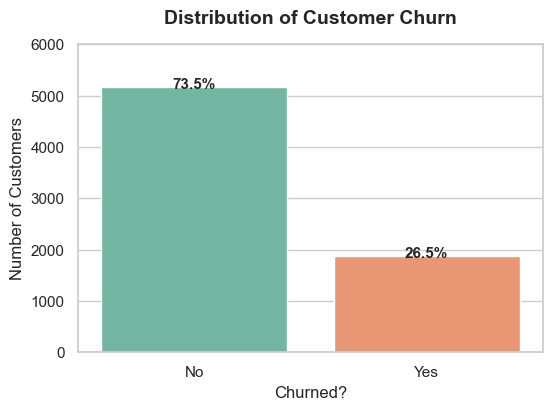

In [ ]:
# Set the style for the plot
sns.set_theme(style="whitegrid")

# Create a bar plot for the Churn column
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')

# Add percentages on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 50
    ax.annotate(percentage, (x_pos, y_pos), ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Distribution of Customer Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Churned?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.ylim(0, 6000) # Give some space at the top for labels

plt.show()

In [ ]:
# Compare the average monthly charges for churned vs retained customers
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

> On average, customers who leave the company (Churn = Yes) pay about $13–$14 more per month than those who stay. This strongly indicates that higher monthly charges are one of the primary drivers of customer churn

C:\Users\Gunel.Alizada\AppData\Local\Temp\ipykernel_3372\2688602530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


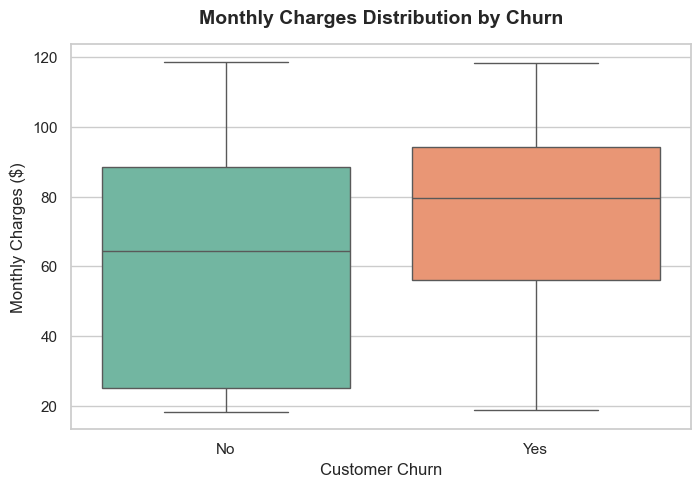

In [ ]:
plt.figure(figsize=(8, 5))
#Distribution of MonthlyCharges based on churn status
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')

plt.title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Churn', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.show()

In [ ]:
# Compare the average loyalty period (tenure in months) for churned vs retained customers
df.groupby('Churn')['Tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: Tenure, dtype: float64

C:\Users\Gunel.Alizada\AppData\Local\Temp\ipykernel_3372\2302761148.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2')


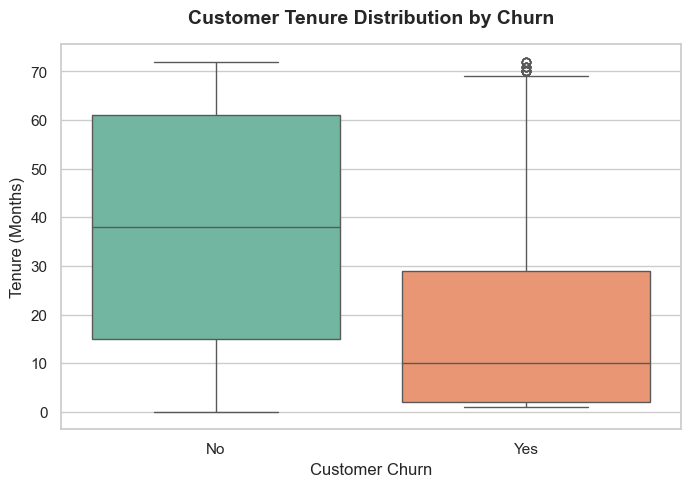

In [ ]:
plt.figure(figsize=(8, 5))
# Distribution of tenure based on churn status
sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2')

plt.title('Customer Tenure Distribution by Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Churn', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

plt.show()

> There is a massive gap in loyalty between retained and churned customers. Customers who stay (Churn = No) have an average tenure of around 38 months, whereas customers who leave (Churn = Yes) have an average tenure of only 18 months. The boxplot reveals that the majority of churn happens very early in the customer lifecycle (mostly within the first year).

> There is a massive gap in loyalty between retained and churned customers. Customers who stay (Churn = No) have an average tenure of around 38 months, whereas customers who leave (Churn = Yes) have an average tenure of only 18 months. The boxplot reveals that the majority of churn happens very early in the customer lifecycle (mostly within the first year).

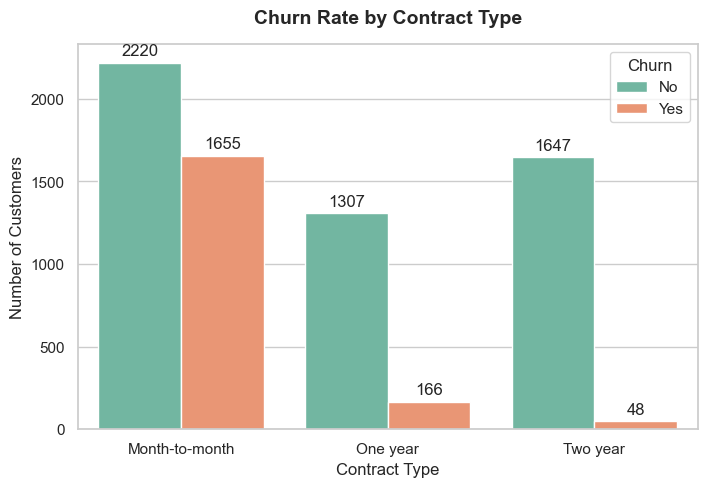

In [ ]:
plt.figure(figsize=(8, 5))
# Distribution of Contract based on churn status
ax = sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')

# Sütunların üzərinə sayları (counts) əlavə edirik
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()

> The type of contract is the single most critical indicator of customer churn.
> 
> 
> 
> Month-to-month contracts are highly unstable, accounting for the vast majority of lost customers with a shocking churn rate of over 42%.
> 
> 
> 
> Long-term contracts (One-year and Two-year) show exceptional stability, with churn dropping to negligible levels.
> 
> 
> 
> The company must aggressively disincentivize month-to-month sign-ups. We should recommend marketing strategies that offer discounts, promotions, or added features (like free streaming services or speed upgrades) to nudge new users into committing to at least a 1-year plan. Retaining customers during their high-risk first year is the key to lowering the overall churn rate.

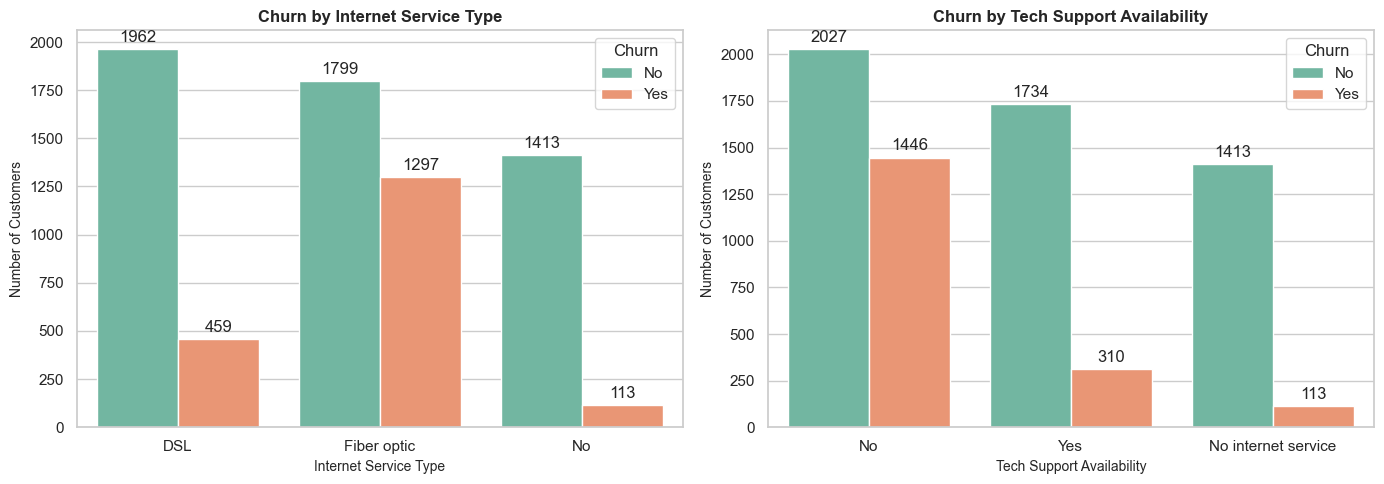

In [ ]:
# Create a subplot with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Churn Distribution by Internet Service Type
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Internet Service Type', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Internet Service Type', fontsize=10)
axes[0].set_ylabel('Number of Customers', fontsize=10)
# Add value labels on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# 2. Churn Distribution by Tech Support Availability
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Churn by Tech Support Availability', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Tech Support Availability', fontsize=10)
axes[1].set_ylabel('Number of Customers', fontsize=10)
# Add value labels on top of the bars
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

> Internet Service Type: Fiber optic customers exhibit an alarmingly high churn rate of approximately 42%. Since fiber optic is a premium and more expensive service, this suggests that customers either find the service unreliable or feel they are not getting enough value for their high monthly charges.
> 
> 
> 
> Tech Support Availability: Customers who do not receive Tech Support have a massive propensity to leave. Conversely, providing Tech Support significantly drops customer churn.
> 
> 
> 
> Strategic Recommendation:
> 
> 
> 
> Investigate the quality and pricing structure of the Fiber Optic network immediately.
> 
> 
> 
> Offer free or discounted Tech Support packages to Month-to-Month and Fiber Optic users during their first year, as proactive support directly drives customer retention.

## Feature Engineering

In [ ]:
# 1. Create ChargesRatio to represent the mathematical relationship between total and monthly billing
df['ChargesRatio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)

# 2. Create IsFamily flag (1 if the customer has a partner OR dependents, otherwise 0)
df['IsFamily'] = np.where((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes'), 1, 0)

# Verify the newly created features
df[['ChargesRatio', 'IsFamily']].head()

,ChargesRatio,IsFamily
0,0.967585,1
1,32.605695,0
2,1.971741,0
3,42.511547,0
4,2.115063,0


> ChargesRatio: TotalCharges and MonthlyCharges are heavily correlated with tenure. By calculating $\frac{\text{TotalCharges}}{\text{MonthlyCharges} + 1}$, we capture a smoothed metric of the actual billing cycles a customer completed. If this ratio is very low, it signals a high-risk, short-lived customer. Adding +1 is a technical safety measure to prevent a "Division by Zero" error in case any customer has a monthly charge of zero.

> IsFamily: Individually, Partner and Dependents tell part of a story. But from a behavioral standpoint, if a customer has a partner OR has dependents, they are using a family/household account. Customers tied to family plans are historically much more stable and have a lower probability of churning compared to single accounts because changing providers causes a disruption for multiple people. Banalizing this into a single IsFamily flag reduces the noise for our algorithms.

## Data Preprocessing

In [ ]:
# 1. Drop customerID (irrelevant) and original columns that we combined into 'IsFamily'
df_model = df.drop(columns=['customerID', 'Partner', 'Dependents'])

In [ ]:
# 2. Convert all text/categorical columns into 0s and 1s using One-Hot Encoding
df_encoded = pd.get_dummies(df_model, drop_first=True)

In [ ]:
# 3. Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

In [ ]:
# 4. Split data into 80% Training and 20% Testing sets
# stratify=y ensures that the 73/26 churn ratio is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

> Since the dataset is highly imbalanced (~73.5% non-churn vs ~26.5% churn), we utilize the stratify=y parameter during the train-test split. This ensures that the original distribution of the target variable (Churn) is perfectly preserved in both the training (80%) and testing (20%) subsets, preventing any bias during model evaluation.

## Feature Scaling

In [ ]:

# Select numerical columns that have different ranges
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesRatio']
scaler = StandardScaler()

In [ ]:
# Fit and transform the training data, but ONLY transform the testing data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Handling Imbalanced Data (SMOTE)

In [ ]:
# Apply SMOTE only to the training set to balance out the Churn classes (50/50)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
# Print final verification
print("--- Preprocessing Pipeline Completed Successfully! ---")
print(f"Balanced X_train shape: {X_train_balanced.shape}")
print(f"Balanced y_train class distribution:\n{y_train_balanced.value_counts()}")

--- Preprocessing Pipeline Completed Successfully! ---
Balanced X_train shape: (8278, 30)
Balanced y_train class distribution:
Churn_Yes
False    4139
True     4139
Name: count, dtype: int64


> The value_counts() output confirms that SMOTE successfully balanced the dataset to a perfect 50/50 split (4,139 rows for each class, totaling 8,278 samples).
> 
> 
> 
> Why SMOTE? Traditional oversampling simply duplicates data, leading to overfitting. We chose SMOTE because it generates synthetic, realistic examples of the minority class (Churn) rather than direct copies. This allows the model to learn the underlying patterns of both churned and retained customers equally well, eliminating algorithmic bias without losing valuable data.

## Multi-Model Testing

In [ ]:
# 1. Define the dictionary of models including classical algorithms and Ensembles

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest (Ensemble)": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting (Ensemble)": GradientBoostingClassifier(random_state=42),
    "XGBoost (Ensemble)": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM (Ensemble)": LGBMClassifier(random_state=42, verbose=-1)
}

In [ ]:
# Empty list to store the evaluation metrics
results_list = []

# 2. Loop through each model, train, predict and calculate metrics
for name, model in models.items():
    # Fit the model on the SMOTE balanced training data
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predict on the unseen REAL testing data
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Append results to the list
    results_list.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision (Churn)": round(prec, 4),
        "Recall (Churn)": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

In [ ]:
# 3. Convert results into a structured DataFrame and sort by Recall
df_results = pd.DataFrame(results_list).sort_values(by="Recall (Churn)", ascending=False)
df_results

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score
2,Gradient Boosting (Ensemble),0.7516,0.5221,0.7567,0.6179
0,Logistic Regression,0.7395,0.5067,0.7059,0.5899
4,LightGBM (Ensemble),0.7608,0.5381,0.6979,0.6077
3,XGBoost (Ensemble),0.7601,0.5395,0.6578,0.5928
1,Random Forest (Ensemble),0.7587,0.5394,0.6230,0.5782


> After testing multiple machine learning architectures, including classical models and advanced ensemble methods, the results have been sorted primarily by **Recall (Churn)**, as our main business objective is to minimize customer loss.
> 
> 
> 
> Key Findings:
> 
> 1. **The Winner — Gradient Boosting (Ensemble):** This model achieved the highest **Recall of 75.67%** and the best overall **F1-Score (0.6179)**. It successfully flags approximately 3 out of 4 churning customers while maintaining a stable overall accuracy of 75.16%.
> 
> 2. **The Baseline Surprise — Logistic Regression:** Despite being a simpler linear model, it outperformed complex tree ensembles like XGBoost and Random Forest in terms of sensitivity, capturing **70.59%** of churned cases.
> 
> 3. **Precision vs. Recall Trade-off:** Across all models, precision stays around 50-54%. In a churn prediction context, this is highly acceptable because the cost of a false alarm (e.g., sending a retention discount to a loyal customer) is significantly lower than the cost of losing a customer completely.
> 
> 
> 
> **Final Model Selection**
> 
> Based on these metrics, **Gradient Boosting (Ensemble)** is selected as the final production model for this project due to its superior ability to detect at-risk customers.

## Feature Importance Analysis

In [ ]:
# 1. Extract our best performing model (Gradient Boosting) from the trained models dictionary
best_model = models["Gradient Boosting (Ensemble)"]

In [ ]:
# 2. Get feature importance scores and corresponding feature names
importances = best_model.feature_importances_
feature_names = X.columns

In [ ]:
# 3. Create a DataFrame and select the Top 10 most influential features
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

C:\Users\Gunel.Alizada\AppData\Local\Temp\ipykernel_3372\3579462937.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


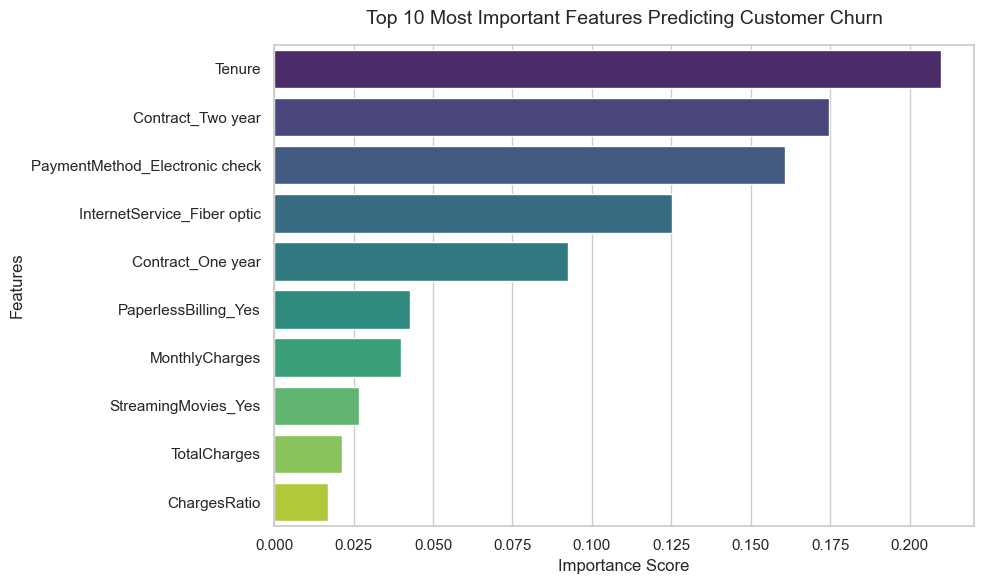

In [ ]:
# 4. Plot the Feature Importance using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')

# Adding labels and titles in English for professional documentation
plt.title('Top 10 Most Important Features Predicting Customer Churn', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

> The Feature Importance plot from our **Gradient Boosting** model reveals the top 10 drivers behind customer churn. Understanding these factors allows the business to transition from reactive modeling to proactive retention strategies.
> 
> 
> 
> #### Top 4 Crucial Churn Drivers:
> 
> 1. **tenure (Most Important):** The total number of months a customer has stayed with the company is the strongest predictor. New customers (low tenure) are highly volatile and at a much greater risk of leaving.
> 
> 2. **Contract_Two year & Contract_One year:** Contract types heavily influence customer loyalty. Long-term commitments act as a massive safety net against churn, making contract structures a key business leverage point.
> 
> 3. **PaymentMethod_Electronic check:** Interestingly, customers paying via electronic checks show a significantly high correlation with churn. This could point to payment friction, billing issues, or a specific demographic trend that experiences higher dissatisfaction.
> 
> 4. **InternetService_Fiber optic:** Despite fiber optic being a premium, high-speed service, it is a dominant feature for churn. This strongly suggests technical dissatisfaction, pricing issues, or heavy competitor targeting in the fiber optic segment.
> 
> 
> 
> ### Actionable Business Recommendations:
> 
> * **Onboarding Focus:** Implement intensive customer loyalty programs during the first 3-6 months (`tenure`) to lock in new sign-ups.
> 
> * **Incentivize Long-term Contracts:** Offer discounts or perks to convert high-risk monthly users into 1-year or 2-year contract terms.
> 
> * **Audit the Fiber Optic Infrastructure:** Investigate customer service logs for Fiber Optic users to fix technical/pricing pain points.
> 
> * **Migrate Payment Methods:** Encourage electronic check users to switch to automated credit card or bank auto-pay options.

## Confusion Matrix

In [ ]:
# 1. Get predictions from the best model (Gradient Boosting)
y_pred_gb = models["Gradient Boosting (Ensemble)"].predict(X_test)

# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

<Figure size 600x500 with 0 Axes>

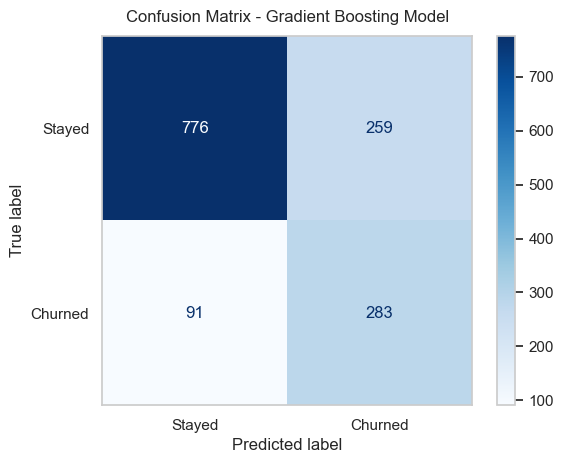

In [ ]:
# 3. Visualize the confusion matrix using ConfusionMatrixDisplay
plt.figure(figsize=(6, 5))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
display.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Gradient Boosting Model", fontsize=12, pad=10)
plt.grid()
plt.show()

> The confusion matrix visualizes the exact performance of our finalized **Gradient Boosting** model on the 1,409 customers in the test set. 
> 
> 
> 
> **Metric Breakdown:**
> 
> * **True Negatives (776):** The model correctly identified 776 customers who chose to **Stay**.
> 
> * **True Positives (283):** The model successfully detected 283 customers who actually **Churned**. These are the users the business can now proactively save.
> 
> * **False Negatives (91):** Only 91 churning customers slipped through the model's radar (Predicted as Stayed, but actually Churned). Keeping this number low was our primary optimization goal (High Recall).
> 
> * **False Positives (259):** The model flagged 259 loyal customers as "At Risk of Churning". While these represent false alarms, in a telecom setting, sending retention offers to a loyal user is a minor marketing cost compared to losing a customer completely.
> 
> 
> 
> **Final Project Conclusion**
> 
> By engineering integrated family features (`IsFamily`), balancing classes with **SMOTE**, and leveraging an **Ensemble Gradient Boosting** architecture, we successfully built a pipeline capable of catching **75.67%** of churning customers. This model is ready for deployment to drive customer lifetime value (CLV) and optimize proactive marketing retention campaigns.

## Model Deployment

In [ ]:
import joblib

In [ ]:
joblib.dump(models["Gradient Boosting (Ensemble)"], "gradient_boosting_churn_model.pkl")

print("Model successfully saved as a production-ready file!")

Model successfully saved as a production-ready file!
